# Stable Diffusion From Scratch — PyTorch
### Full pipeline: VAE · CLIP · U-Net · DDPM · Training · Inference


## 1. Environment Setup

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import math, numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tqdm as tqdm_mod

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 2. Global Configuration

> **Memory budget for Colab free T4**  
> `IMAGE_SIZE=64` keeps the U-Net < 5 GB during training.  
> Raise to 128 if you have a paid Colab or a larger GPU.

In [ ]:
# ── Image / latent dims ───────────────────────────────────────────────────────
IMAGE_SIZE   = 64          # spatial size of images fed into the VAE
LATENT_SIZE  = IMAGE_SIZE // 8   # VAE down-samples 8×  ->  8 for IMAGE_SIZE=64

# ── Dataset (fully synthetic — no downloads needed) ───────────────────────────
N_SAMPLES    = 200         # total synthetic training samples
VOCAB_SIZE   = 256         # tiny token vocabulary
SEQ_LEN      = 16          # token sequence length (real CLIP uses 77)

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE       = 2       # keep small for 15 GB GPU
GRAD_ACCUM       = 4       # effective batch = 2 * GRAD_ACCUM = 8
LR               = 1e-4
VAE_EPOCHS       = 20
DIFFUSION_EPOCHS = 25
DDPM_STEPS       = 1000    # training noise steps
INFER_STEPS      = 20      # denoising steps at inference

# ── Memory helpers ────────────────────────────────────────────────────────────
def free_mem():
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

print(f"IMAGE_SIZE   = {IMAGE_SIZE}  ->  latent {LATENT_SIZE}x{LATENT_SIZE}x4")
print(f"BATCH_SIZE   = {BATCH_SIZE}  (grad_accum={GRAD_ACCUM})")


IMAGE_SIZE   = 64  ->  latent 8x8x4
BATCH_SIZE   = 2  (grad_accum=4)


## 3. Attention Modules

In [ ]:
class SelfAttention(nn.Module):
    """Multi-head self-attention.
    Input  : (B, T, D)
    Output : (B, T, D)
    """
    def __init__(self, n_heads, d_embed, in_proj_bias=True, out_proj_bias=True):
        super().__init__()
        self.in_proj  = nn.Linear(d_embed, 3 * d_embed, bias=in_proj_bias)
        self.out_proj = nn.Linear(d_embed, d_embed,     bias=out_proj_bias)
        self.n_heads  = n_heads
        self.d_head   = d_embed // n_heads

    def forward(self, x, causal_mask=False):
        B, T, D = x.shape                               # (B, T, D)
        H, Dh   = self.n_heads, self.d_head

        q, k, v = self.in_proj(x).chunk(3, dim=-1)      # each (B, T, D)
        q = q.view(B, T, H, Dh).transpose(1, 2)         # (B, H, T, Dh)
        k = k.view(B, T, H, Dh).transpose(1, 2)
        v = v.view(B, T, H, Dh).transpose(1, 2)

        w = q @ k.transpose(-1, -2) / math.sqrt(Dh)    # (B, H, T, T)
        if causal_mask:
            mask = torch.ones_like(w, dtype=torch.bool).triu(1)
            w.masked_fill_(mask, float("-inf"))
        w = F.softmax(w, dim=-1)

        out = (w @ v).transpose(1, 2).reshape(B, T, D)  # (B, T, D)
        return self.out_proj(out)


class CrossAttention(nn.Module):
    """Multi-head cross-attention (query from x, key/value from context y).
    x : (B, Tq, Dq)
    y : (B, Tk, Dk)
    Output : (B, Tq, Dq)
    """
    def __init__(self, n_heads, d_embed, d_cross, in_proj_bias=True, out_proj_bias=True):
        super().__init__()
        self.q_proj   = nn.Linear(d_embed, d_embed, bias=in_proj_bias)
        self.k_proj   = nn.Linear(d_cross, d_embed, bias=in_proj_bias)
        self.v_proj   = nn.Linear(d_cross, d_embed, bias=in_proj_bias)
        self.out_proj = nn.Linear(d_embed, d_embed, bias=out_proj_bias)
        self.n_heads  = n_heads
        self.d_head   = d_embed // n_heads

    def forward(self, x, y):
        B, Tq, Dq = x.shape
        H, Dh     = self.n_heads, self.d_head

        q = self.q_proj(x).view(B, -1, H, Dh).transpose(1, 2)  # (B,H,Tq,Dh)
        k = self.k_proj(y).view(B, -1, H, Dh).transpose(1, 2)  # (B,H,Tk,Dh)
        v = self.v_proj(y).view(B, -1, H, Dh).transpose(1, 2)  # (B,H,Tk,Dh)

        w   = q @ k.transpose(-1, -2) / math.sqrt(Dh)           # (B,H,Tq,Tk)
        w   = F.softmax(w, dim=-1)
        out = (w @ v).transpose(1, 2).contiguous().view(B, Tq, Dq)  # (B,Tq,Dq)
        return self.out_proj(out)


## 4. VAE — Encoder & Decoder

> The encoder compresses `(B,3,H,W)` → `(B,4,H/8,W/8)` latents.  
> The decoder reconstructs `(B,4,H/8,W/8)` → `(B,3,H,W)` images.  
> A KL loss keeps the latent distribution close to N(0,1).

In [ ]:
# ── Shared building blocks ────────────────────────────────────────────────────

class VAE_ResidualBlock(nn.Module):
    """GroupNorm → SiLU → Conv × 2 with residual skip."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.gn1  = nn.GroupNorm(min(32, in_ch),  in_ch)
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, padding=1)
        self.gn2  = nn.GroupNorm(min(32, out_ch), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip  = nn.Identity() if in_ch == out_ch else nn.Conv2d(in_ch, out_ch, 1)

    def forward(self, x):
        r = x
        x = F.silu(self.gn1(x))
        x = self.conv1(x)
        x = F.silu(self.gn2(x))
        x = self.conv2(x)
        return x + self.skip(r)


class VAE_AttentionBlock(nn.Module):
    """Spatial self-attention block for the VAE bottleneck."""
    def __init__(self, ch):
        super().__init__()
        self.gn  = nn.GroupNorm(min(32, ch), ch)
        self.attn = SelfAttention(1, ch)

    def forward(self, x):
        B, C, H, W = x.shape
        r = x
        x = self.gn(x)
        x = x.view(B, C, H*W).transpose(-1, -2)   # (B, H*W, C)
        x = self.attn(x)                            # (B, H*W, C)
        x = x.transpose(-1, -2).view(B, C, H, W)   # (B, C, H, W)
        return x + r


# ── Encoder ────────────────────────────────────────────────────────────────────

class VAE_Encoder(nn.Sequential):
    """
    Input  : x (B, 3, H, W)  |  noise (B, 4, H/8, W/8)
    Output : z (B, 4, H/8, W/8), mean (B,4,H/8,W/8), log_var (B,4,H/8,W/8)
    """
    # Channel sizes: 3 -> 64 -> 128 -> 256 -> 512 -> 8 (split into mean+logvar)
    def __init__(self):
        super().__init__(
            #x (B, 3, H, W)
            nn.Conv2d(3, 64,  3, padding=1),           # (B,  64, H,   W)
            VAE_ResidualBlock(64,  64),
            nn.Conv2d(64,  64,  3, stride=2, padding=0),# (B,  64, H/2, W/2)
            VAE_ResidualBlock(64,  128),
            nn.Conv2d(128, 128, 3, stride=2, padding=0),# (B, 128, H/4, W/4)
            VAE_ResidualBlock(128, 256),
            nn.Conv2d(256, 256, 3, stride=2, padding=0),# (B, 256, H/8, W/8)
            VAE_ResidualBlock(256, 256),
            VAE_AttentionBlock(256),
            VAE_ResidualBlock(256, 256),
            nn.GroupNorm(min(32, 256), 256),
            nn.SiLU(),
            nn.Conv2d(256, 8, 3, padding=1),            # (B,   8, H/8, W/8)
            nn.Conv2d(8,   8, 1),                        # (B,   8, H/8, W/8)
        )

    def forward(self, x, noise):
        # x: (B,3,H,W)  noise: (B,4,H/8,W/8)
        for m in self:
            if getattr(m, 'stride', None) == (2, 2):
                x = F.pad(x, (0, 1, 0, 1))
            x = m(x)
        # x: (B, 8, H/8, W/8)
        ## B,8,8,8
        mean, log_var = x.chunk(2, dim=1)              # each (B, 4, H/8, W/8)
        log_var = torch.clamp(log_var, -30, 20)
        z = mean + log_var.exp().sqrt() * noise         # reparameterisation
        z = z * 0.18215                                 # SD scaling constant
        return z, mean, log_var


# ── Decoder ────────────────────────────────────────────────────────────────────

class VAE_Decoder(nn.Sequential):
    """
    Input  : z (B, 4, 8, 8)
    Output : x_recon (B, 3, H, W)
    """
    def __init__(self):
        super().__init__(
            nn.Conv2d(4,   4,   1),
            nn.Conv2d(4,   256, 3, padding=1),          # (B, 256, H/8, W/8)
            VAE_ResidualBlock(256, 256),
            VAE_AttentionBlock(256),
            VAE_ResidualBlock(256, 256),
            nn.Upsample(scale_factor=2),                # (B, 256, H/4, W/4)
            nn.Conv2d(256, 256, 3, padding=1),
            VAE_ResidualBlock(256, 128),
            nn.Upsample(scale_factor=2),                # (B, 128, H/2, W/2)
            nn.Conv2d(128, 128, 3, padding=1),
            VAE_ResidualBlock(128, 64),
            nn.Upsample(scale_factor=2),                # (B,  64, H,   W)
            nn.Conv2d(64,  64,  3, padding=1),
            VAE_ResidualBlock(64, 64),
            nn.GroupNorm(min(32, 64), 64),
            nn.SiLU(),
            nn.Conv2d(64, 3, 3, padding=1),             # (B,   3, H,   W)
        )

    def forward(self, z):
        z = z / 0.18215
        for m in self:
            z = m(z)
        return z


## 5. Tiny CLIP Text Encoder

> We use a **lightweight CLIP** (d_model=128, 4 layers) so it fits in free-tier Colab.  
> The vocabulary and sequences are also shrunk (`VOCAB_SIZE=256, SEQ_LEN=16`).

In [ ]:
# Dimensions tuned for Colab free GPU
CLIP_DIM    = 128   # text embedding size
CLIP_HEADS  = 4
CLIP_LAYERS = 4


class CLIPEmbedding(nn.Module):
    """Token embedding + learned positional embedding.
    Input  : tokens (B, T)
    Output : embeddings (B, T, D)
    """
    def __init__(self, vocab, d, seq_len):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab, d)
        self.pos_emb = nn.Parameter(torch.zeros(seq_len, d))

    def forward(self, t):
        return self.tok_emb(t) + self.pos_emb    # (B, T, D)


class CLIPLayer(nn.Module):
    """Single transformer layer: LayerNorm → CausalSelfAttn + LayerNorm → FFN.
    Input/Output: (B, T, D)
    """
    def __init__(self, n_head, d):
        super().__init__()
        self.ln1  = nn.LayerNorm(d)
        self.attn = SelfAttention(n_head, d)
        self.ln2  = nn.LayerNorm(d)
        self.fc1  = nn.Linear(d, 4 * d)
        self.fc2  = nn.Linear(4 * d, d)

    def forward(self, x):
        x = x + self.attn(self.ln1(x), causal_mask=True)
        r = x
        x = self.fc1(self.ln2(x))
        x = x * torch.sigmoid(1.702 * x)   # QuickGELU
        x = self.fc2(x)
        return x + r


class CLIP(nn.Module):
    """
    Input  : tokens (B, SEQ_LEN)   — long integers in [0, VOCAB_SIZE)
    Output : context (B, SEQ_LEN, CLIP_DIM)
    """
    def __init__(self):
        super().__init__()
        self.embedding = CLIPEmbedding(VOCAB_SIZE, CLIP_DIM, SEQ_LEN)
        self.layers    = nn.ModuleList([CLIPLayer(CLIP_HEADS, CLIP_DIM)
                                        for _ in range(CLIP_LAYERS)])
        self.ln_final  = nn.LayerNorm(CLIP_DIM)

    def forward(self, tokens):
        x = self.embedding(tokens.long())  # (B, T, D)
        for layer in self.layers:
            x = layer(x)
        return self.ln_final(x)            # (B, T, CLIP_DIM)


## 6. Compact U-Net (Diffusion Model)

> Channels are reduced (`320→128`, `640→256`, `1280→512`) to fit 15 GB VRAM.
> Cross-attention context dimension is `CLIP_DIM=128` instead of 768.

In [ ]:
# ── U-Net building blocks ─────────────────────────────────────────────────────

class UNET_ResidualBlock(nn.Module):
    """Feature + time-embedding residual block.
    feature : (B, in_ch, H, W)
    time    : (B, 4*time_embd)
    output  : (B, out_ch, H, W)
    """
    def __init__(self, in_ch, out_ch, n_time=None):
        super().__init__()
        if n_time is None:
            n_time = TIME_EMBD * 4
        self.gn_f  = nn.GroupNorm(min(32, in_ch), in_ch)
        self.conv_f = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.fc_t   = nn.Linear(n_time, out_ch)
        self.gn_m  = nn.GroupNorm(min(32, out_ch), out_ch)
        self.conv_m = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip   = nn.Identity() if in_ch == out_ch                       else nn.Conv2d(in_ch, out_ch, 1)

    def forward(self, feat, time):
        r    = feat
        feat = F.silu(self.gn_f(feat))
        feat = self.conv_f(feat)
        t    = self.fc_t(F.silu(time))              # (B, out_ch)
        feat = feat + t[:, :, None, None]            # broadcast over H,W
        feat = F.silu(self.gn_m(feat))
        feat = self.conv_m(feat)
        return feat + self.skip(r)


class UNET_AttentionBlock(nn.Module):
    """Spatial self-attention + cross-attention + GeGLU-FFN.
    x       : (B, ch, H, W)
    context : (B, T, CLIP_DIM)
    output  : (B, ch, H, W)
    """
    def __init__(self, n_head, n_embd, d_ctx=CLIP_DIM):
        super().__init__()
        ch = n_head * n_embd
        self.gn       = nn.GroupNorm(min(32, ch), ch, eps=1e-6)
        self.conv_in  = nn.Conv2d(ch, ch, 1)
        self.ln1      = nn.LayerNorm(ch)
        self.attn1    = SelfAttention(n_head, ch, in_proj_bias=False)
        self.ln2      = nn.LayerNorm(ch)
        self.attn2    = CrossAttention(n_head, ch, d_ctx, in_proj_bias=False)
        self.ln3      = nn.LayerNorm(ch)
        self.ff1      = nn.Linear(ch, 4 * ch * 2)  # GeGLU uses 2× width
        self.ff2      = nn.Linear(4 * ch, ch)
        self.conv_out = nn.Conv2d(ch, ch, 1)

    def forward(self, x, ctx):
        B, C, H, W  = x.shape
        long_skip   = x
        x = self.conv_in(self.gn(x))
        x = x.view(B, C, H*W).transpose(-1, -2)     # (B, H*W, C)
        s = x
        x = self.attn1(self.ln1(x)) + s       # self-attn
        s = x
        x = self.attn2(self.ln2(x), ctx) + s  # cross-attn
        s = x


        gate, val = self.ff1(self.ln3(x)).chunk(2, dim=-1)
        x = self.ff2(gate * F.gelu(val)) + s          # GeGLU-FFN

        x = x.transpose(-1, -2).view(B, C, H, W)
        return self.conv_out(x) + long_skip


class SwitchSequential(nn.Sequential):
    """Sequential that routes extra args to the right layer type."""
    def forward(self, x, ctx, time):
        for layer in self:
            if isinstance(layer, UNET_AttentionBlock):
                x = layer(x, ctx)
            elif isinstance(layer, UNET_ResidualBlock):
                x = layer(x, time)
            else:
                x = layer(x)
        return x


class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 3, padding=1)
    def forward(self, x):
        return self.conv(F.interpolate(x, scale_factor=2, mode='nearest'))


# ── Channel layout (compact for 15 GB GPU) ────────────────────────────────────
# Full SD uses  [320, 640, 1280] — we use [128, 256, 512]
TIME_EMBD = 128         # sinusoidal embedding size
C1, C2, C3 = 128, 256, 512


class UNET(nn.Module):
    """
    x       : (B, 4,  Lh, Lw)           latent
    ctx     : (B, T,  CLIP_DIM)         text context
    time    : (B, 4*TIME_EMBD)          time embedding
    output  : (B, C1, Lh, Lw)
    """
    def __init__(self):
        super().__init__()
        self.encoders = nn.ModuleList([
            SwitchSequential(nn.Conv2d(4,  C1, 3, padding=1)),        # x       : (B, 4,  Lh, Lw)
            SwitchSequential(UNET_ResidualBlock(C1, C1),
                             UNET_AttentionBlock(4, C1//4)),           # 1
            SwitchSequential(UNET_ResidualBlock(C1, C1),
                             UNET_AttentionBlock(4, C1//4)),           # 2
            SwitchSequential(nn.Conv2d(C1, C1, 3, stride=2, padding=1)),# 3
            SwitchSequential(UNET_ResidualBlock(C1, C2),
                             UNET_AttentionBlock(4, C2//4)),           # 4
            SwitchSequential(UNET_ResidualBlock(C2, C2),
                             UNET_AttentionBlock(4, C2//4)),           # 5
            SwitchSequential(nn.Conv2d(C2, C2, 3, stride=2, padding=1)),# 6
            SwitchSequential(UNET_ResidualBlock(C2, C3),
                             UNET_AttentionBlock(4, C3//4)),           # 7
            SwitchSequential(UNET_ResidualBlock(C3, C3),
                             UNET_AttentionBlock(4, C3//4)),           # 8
            SwitchSequential(nn.Conv2d(C3, C3, 3, stride=2, padding=1)),# 9
            SwitchSequential(UNET_ResidualBlock(C3, C3)),               # 10
            SwitchSequential(UNET_ResidualBlock(C3, C3)),               # 11
        ])

        self.bottleneck = SwitchSequential(
            UNET_ResidualBlock(C3, C3),
            UNET_AttentionBlock(4, C3//4),
            UNET_ResidualBlock(C3, C3),
        )

        self.decoders = nn.ModuleList([
            SwitchSequential(UNET_ResidualBlock(C3*2, C3)),             # 0
            SwitchSequential(UNET_ResidualBlock(C3*2, C3)),             # 1
            SwitchSequential(UNET_ResidualBlock(C3*2, C3), Upsample(C3)),# 2
            SwitchSequential(UNET_ResidualBlock(C3+C3, C3),
                             UNET_AttentionBlock(4, C3//4)),            # 3
            SwitchSequential(UNET_ResidualBlock(C3+C3, C3),
                             UNET_AttentionBlock(4, C3//4)),            # 4
            SwitchSequential(UNET_ResidualBlock(C3+C2, C3),
                             UNET_AttentionBlock(4, C3//4), Upsample(C3)),# 5
            SwitchSequential(UNET_ResidualBlock(C3+C2, C2),
                             UNET_AttentionBlock(4, C2//4)),            # 6
            SwitchSequential(UNET_ResidualBlock(C2+C2, C2),
                             UNET_AttentionBlock(4, C2//4)),            # 7
            SwitchSequential(UNET_ResidualBlock(C2+C1, C2),
                             UNET_AttentionBlock(4, C2//4), Upsample(C2)),# 8
            SwitchSequential(UNET_ResidualBlock(C2+C1, C1),
                             UNET_AttentionBlock(4, C1//4)),            # 9
            SwitchSequential(UNET_ResidualBlock(C1+C1, C1),
                             UNET_AttentionBlock(4, C1//4)),            # 10
            SwitchSequential(UNET_ResidualBlock(C1+C1, C1),
                             UNET_AttentionBlock(4, C1//4)),            # 11
        ])

    def forward(self, x, ctx, time):
        skips = []
        for layer in self.encoders:
            x = layer(x, ctx, time)
            skips.append(x)
        x = self.bottleneck(x, ctx, time)
        for layer in self.decoders:
            x = torch.cat([x, skips.pop()], dim=1)
            x = layer(x, ctx, time)
        return x                 # (B, C1, Lh, Lw)


class UNET_OutputLayer(nn.Module):
    """GroupNorm → SiLU → Conv to get back 4-channel noise prediction.
    Input  : (B, C1, Lh, Lw)
    Output : (B, 4,  Lh, Lw)
    """
    def __init__(self):
        super().__init__()
        self.gn   = nn.GroupNorm(min(32, C1), C1)
        self.conv = nn.Conv2d(C1, 4, 3, padding=1)

    def forward(self, x):
        return self.conv(F.silu(self.gn(x)))


class Diffusion(nn.Module):
    """
    latent  : (B, 4,        Lh, Lw)
    context : (B, SEQ_LEN,  CLIP_DIM)
    t_emb   : (B, TIME_EMBD)
    output  : (B, 4,        Lh, Lw)   predicted noise
    """
    def __init__(self):
        super().__init__()
        self.time_fc1 = nn.Linear(TIME_EMBD,   4 * TIME_EMBD)
        self.time_fc2 = nn.Linear(4*TIME_EMBD, 4 * TIME_EMBD)
        self.unet     = UNET()
        self.out      = UNET_OutputLayer()

    def forward(self, latent, context, t_emb):
        t = F.silu(self.time_fc1(t_emb))   # (B, 4*TIME_EMBD)
        t = self.time_fc2(t)
        x = self.unet(latent, context, t)   # (B, C1, Lh, Lw)
        return self.out(x)                  # (B, 4,  Lh, Lw)


## 7. DDPM Noise Scheduler

In [ ]:
class DDPMSampler:
    """
    Implements the forward (add noise) and reverse (denoise) diffusion process.

    Key tensors:
      betas          : (T,)   noise schedule
      alphas         : (T,)   = 1 - beta
      alphas_cumprod : (T,)   ᾱ_t = ∏ alpha_s for s<=t
    """
    def __init__(self, generator: torch.Generator,
                 num_train_steps=1000,
                 beta_start=0.00085, beta_end=0.0120):
        # Quadratic noise schedule (same as SD v1.5)
        self.betas          = torch.linspace(beta_start**0.5, beta_end**0.5,
                                              num_train_steps) ** 2
        self.alphas         = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.one            = torch.tensor(1.0)
        self.generator      = generator
        self.num_train_steps = num_train_steps
        # Default timestep sequence (reversed for inference)
        self.timesteps = torch.from_numpy(
            np.arange(0, num_train_steps)[::-1].copy())

    def set_inference_timesteps(self, n=20):
        step = self.num_train_steps // n
        ts   = (np.arange(0, n) * step).round()[::-1].copy().astype(np.int64)
        self.timesteps       = torch.from_numpy(ts)
        self.num_infer_steps = n

    def _prev_t(self, t):
        return t - self.num_train_steps // self.num_infer_steps

    def _variance(self, t):
        prev_t = self._prev_t(t)
        acp    = self.alphas_cumprod
        ap     = acp[t]
        ap_prev = acp[prev_t] if prev_t >= 0 else self.one
        beta_t  = 1 - ap / ap_prev
        var     = (1 - ap_prev) / (1 - ap) * beta_t
        return torch.clamp(var, min=1e-20)

    def set_strength(self, strength=1.0):
        start = self.num_infer_steps - int(self.num_infer_steps * strength)
        self.timesteps = self.timesteps[start:]

    # ── Forward: q(x_t | x_0) ─────────────────────────────────────────────────
    def add_noise(self, x0: torch.Tensor,
                  timesteps: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        x0        : (B, 4, Lh, Lw)   clean latent
        timesteps : (B,)              integer timestep indices
        Returns   : (noisy_x, noise)  both (B, 4, Lh, Lw)
        """
        acp = self.alphas_cumprod.to(x0.device, x0.dtype)
        ts  = timesteps.to(x0.device)
        sqrt_acp = acp[ts] ** 0.5
        sqrt_1ma = (1 - acp[ts]) ** 0.5
        for arr in [sqrt_acp, sqrt_1ma]:
            while arr.dim() < x0.dim():
                arr.unsqueeze_(-1)
        noise   = torch.randn_like(x0)
        noisy_x = sqrt_acp * x0 + sqrt_1ma * noise
        return noisy_x, noise

    # ── Reverse: p(x_{t-1} | x_t) ────────────────────────────────────────────
    def step(self, t: int, x_t: torch.Tensor,
             eps_pred: torch.Tensor) -> torch.Tensor:
        """
        t        : scalar int timestep
        x_t      : (B, 4, Lh, Lw)
        eps_pred : (B, 4, Lh, Lw)   predicted noise
        Returns  : x_{t-1} (B, 4, Lh, Lw)
        """
        prev_t   = self._prev_t(t)
        acp      = self.alphas_cumprod
        ap       = acp[t]
        ap_prev  = acp[prev_t] if prev_t >= 0 else self.one
        beta_t   = 1 - ap / ap_prev
        bp_t     = 1 - ap
        bp_prev  = 1 - ap_prev
        a_t      = ap / ap_prev

        x0_pred  = (x_t - bp_t**0.5 * eps_pred) / ap**0.5
        c0       = ap_prev**0.5 * beta_t / bp_t
        ct       = a_t**0.5 * bp_prev / bp_t
        mu       = c0 * x0_pred + ct * x_t

        noise = 0
        if t > 0:
            noise = (self._variance(t)**0.5 *
                     torch.randn_like(x_t, generator=self.generator))
        return mu + noise


## 8. Utility Functions

In [ ]:
def sinusoidal_time_embedding(timestep: int, dim: int = TIME_EMBD) -> torch.Tensor:
    """
    Sinusoidal positional encoding for a scalar timestep.
    Output : (1, dim)
    """
    half  = dim // 2
    freqs = torch.pow(10000, -torch.arange(half, dtype=torch.float32) / half)
    x     = torch.tensor([timestep], dtype=torch.float32)[:, None] * freqs[None]
    return torch.cat([torch.cos(x), torch.sin(x)], dim=-1)   # (1, dim)


def vae_kl_loss(mean, log_var):
    """KL( N(mean,exp(log_var)) || N(0,1) ) averaged over batch & latent dims."""
    return -0.5 * torch.mean(1 + log_var - mean.pow(2) - log_var.exp())


def tensor_to_pil(t: torch.Tensor) -> Image.Image:
    """Convert (3,H,W) float tensor in [-1,1] to a PIL RGB image."""
    t = t.detach().cpu().float().clamp(-1, 1)
    t = ((t + 1) / 2 * 255).byte()
    return Image.fromarray(t.permute(1, 2, 0).numpy())


def count_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters())


## 9. Real Image Dataset (CIFAR-10 — auto-downloads)

> **No manual uploads needed.**  
> We use `torchvision.datasets.CIFAR10` which downloads ~170 MB automatically  
> the first time and caches to `/content/data/` in Colab.  
>  
> CIFAR-10 has **10 classes** — each class label becomes the text "prompt"  
> (tokenised as a short integer sequence) so text-to-image is class-conditioned.  
>  
> Images are resized from 32×32 → `IMAGE_SIZE` (64×64) and normalised to `[-1, 1]`.


100%|██████████| 170M/170M [00:16<00:00, 10.2MB/s]


RealImageDataset: 2000 samples  (train)  image size = 64x64
  sample image  shape : (3, 64, 64)   min=-0.99  max=0.98
  sample tokens shape : (16,)
  sample tokens       : [78, 85, 92, 99, 106, 113, 120, 127, 134, 141, 148, 155, 162, 169, 176, 183]


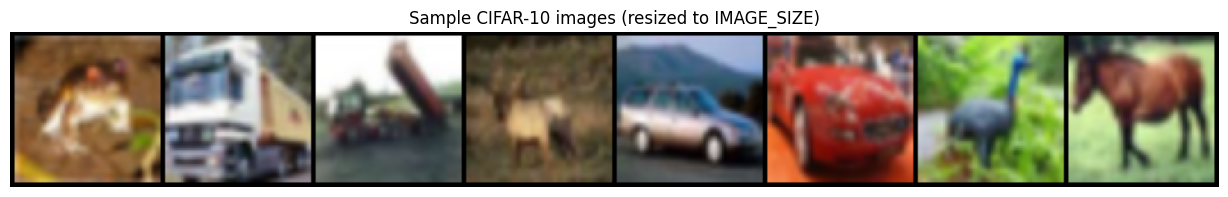

In [ ]:
import torchvision
import torchvision.transforms as T

# ── CIFAR-10 class names → used as text prompts ───────────────────────────────
CIFAR_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

def label_to_tokens(label: int, seq_len: int = SEQ_LEN) -> torch.Tensor:
    """
    Convert an integer class label to a fixed-length token sequence.
    We spread the label's bytes across the sequence so every position
    carries information.  This is a simple deterministic tokeniser that
    fits our tiny CLIP vocab (VOCAB_SIZE=256).

    label   : int  0-9
    Returns : (seq_len,) long tensor
    """#label =3
    # Repeat the label value with slight offsets to fill SEQ_LEN slots
    tokens = [(label * 13 + i * 7) % VOCAB_SIZE for i in range(seq_len)]
    return torch.tensor(tokens, dtype=torch.long)

# ── Transform: resize to IMAGE_SIZE, convert to [-1, 1] ──────────────────────
cifar_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=T.InterpolationMode.BILINEAR),
    T.ToTensor(),                       # [0, 1]
    T.Normalize([0.5, 0.5, 0.5],        # → [-1, 1]
                [0.5, 0.5, 0.5]),
])

class RealImageDataset(Dataset):
    """
    Wraps torchvision CIFAR-10 and returns (image_tensor, token_tensor).

    image  : (3, IMAGE_SIZE, IMAGE_SIZE)  float32  in [-1, 1]
    tokens : (SEQ_LEN,)                   int64    in [0, VOCAB_SIZE)

    Output shapes
    -------------
    images  : (N, 3, IMAGE_SIZE, IMAGE_SIZE)
    tokens  : (N, SEQ_LEN)
    """
    def __init__(self, root="/content/data", train=True, max_samples=2000):
        self.cifar = torchvision.datasets.CIFAR10(
            root=root, train=train, download=True, transform=cifar_transform
        )
        # Optionally cap the dataset size to keep training fast on free Colab
        self.indices = list(range(min(max_samples, len(self.cifar))))
        print(f"RealImageDataset: {len(self.indices)} samples  "
              f"({'train' if train else 'test'})  "
              f"image size = {IMAGE_SIZE}x{IMAGE_SIZE}")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label          = self.cifar[self.indices[idx]]   # img: (3,H,W)
        tokens              = label_to_tokens(label)           # (SEQ_LEN,)
        return img, tokens


# ── Build dataset & dataloader ────────────────────────────────────────────────
dataset    = RealImageDataset(root="/content/data", train=True, max_samples=2000)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE,
                        shuffle=True, num_workers=2, pin_memory=(DEVICE=="cuda"))

# ── Quick sanity check ────────────────────────────────────────────────────────
sample_img, sample_tok = dataset[0]
print(f"  sample image  shape : {tuple(sample_img.shape)}   "
      f"min={sample_img.min():.2f}  max={sample_img.max():.2f}")
print(f"  sample tokens shape : {tuple(sample_tok.shape)}")
print(f"  sample tokens       : {sample_tok.tolist()}")

# Show a grid of real images
n_show = min(8, len(dataset))
imgs_show = torch.stack([dataset[i][0] for i in range(n_show)])
grid = torchvision.utils.make_grid(
    (imgs_show * 0.5 + 0.5).clamp(0, 1), nrow=n_show
)
plt.figure(figsize=(14, 2))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("Sample CIFAR-10 images (resized to IMAGE_SIZE)")
plt.tight_layout(); plt.show()


## 10. Instantiate Models & Print Output Shapes

In [ ]:
encoder   = VAE_Encoder().to(DEVICE)
decoder   = VAE_Decoder().to(DEVICE)
clip_enc  = CLIP().to(DEVICE)
diffusion = Diffusion().to(DEVICE)

# ── Parameter counts ──────────────────────────────────────────────────────────
print("Parameter counts")
print(f"  VAE Encoder  : {count_params(encoder):>10,}")
print(f"  VAE Decoder  : {count_params(decoder):>10,}")
print(f"  CLIP         : {count_params(clip_enc):>10,}")
print(f"  Diffusion    : {count_params(diffusion):>10,}")
total = sum(count_params(m) for m in [encoder, decoder, clip_enc, diffusion])
print(f"  TOTAL        : {total:>10,}")

# ── Forward-pass shape check (all tensors on DEVICE) ─────────────────────────
print("\nOutput shape verification (B=1, single forward pass)")
with torch.no_grad():
    dummy_img    = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE,  device=DEVICE)
    dummy_noise  = torch.randn(1, 4, LATENT_SIZE, LATENT_SIZE, device=DEVICE)
    dummy_tokens = torch.randint(0, VOCAB_SIZE, (1, SEQ_LEN),  device=DEVICE)

    z, mu, lv    = encoder(dummy_img, dummy_noise)
    print(f"  VAE Encoder   input  : {tuple(dummy_img.shape)}")
    print(f"  VAE Encoder   latent : {tuple(z.shape)}  (z)")
    print(f"  VAE Encoder   mean   : {tuple(mu.shape)}")
    print(f"  VAE Encoder   logvar : {tuple(lv.shape)}")

    x_recon      = decoder(z)
    print(f"  VAE Decoder   output : {tuple(x_recon.shape)}")

    ctx          = clip_enc(dummy_tokens)
    print(f"  CLIP          tokens : {tuple(dummy_tokens.shape)}")
    print(f"  CLIP          context: {tuple(ctx.shape)}")

    t_emb        = sinusoidal_time_embedding(500).to(DEVICE)   # (1, TIME_EMBD)
    eps_pred     = diffusion(z, ctx, t_emb)
    print(f"  Diffusion     latent : {tuple(z.shape)}")
    print(f"  Diffusion     time   : {tuple(t_emb.shape)}")
    print(f"  Diffusion     eps    : {tuple(eps_pred.shape)}")

    # Clean up
    del dummy_img, dummy_noise, dummy_tokens, z, mu, lv, x_recon, ctx, t_emb, eps_pred
    if DEVICE == "cuda":
        torch.cuda.empty_cache()


Parameter counts
  VAE Encoder  :  4,644,752
  VAE Decoder  :  4,081,751
  CLIP         :    828,160
  Diffusion    : 135,846,276
  TOTAL        : 145,400,939

Output shape verification (B=1, single forward pass)
  VAE Encoder   input  : (1, 3, 64, 64)
  VAE Encoder   latent : (1, 4, 8, 8)  (z)
  VAE Encoder   mean   : (1, 4, 8, 8)
  VAE Encoder   logvar : (1, 4, 8, 8)
  VAE Decoder   output : (1, 3, 64, 64)
  CLIP          tokens : (1, 16)
  CLIP          context: (1, 16, 128)
  Diffusion     latent : (1, 4, 8, 8)
  Diffusion     time   : (1, 128)
  Diffusion     eps    : (1, 4, 8, 8)


## 11. Train the VAE

> Loss = MSE (reconstruction) + λ·KL (latent regularisation)  
> We use gradient accumulation to simulate a larger effective batch size.

  Training VAE
  Epoch 1/20 | loss=0.0820  recon=0.0819  kl=1.4499
  Epoch 2/20 | loss=0.0420  recon=0.0418  kl=2.0426
  Epoch 3/20 | loss=0.0298  recon=0.0295  kl=2.2628
  Epoch 4/20 | loss=0.0199  recon=0.0196  kl=2.6525
  Epoch 5/20 | loss=0.0178  recon=0.0175  kl=2.9009
  Epoch 6/20 | loss=0.0158  recon=0.0155  kl=3.0904
  Epoch 7/20 | loss=0.0146  recon=0.0143  kl=3.3510
  Epoch 8/20 | loss=0.0127  recon=0.0124  kl=3.5107
  Epoch 9/20 | loss=0.0127  recon=0.0123  kl=3.6476
  Epoch 10/20 | loss=0.0120  recon=0.0116  kl=3.7289
  Epoch 11/20 | loss=0.0117  recon=0.0113  kl=3.7612
  Epoch 12/20 | loss=0.0109  recon=0.0105  kl=3.7871
  Epoch 13/20 | loss=0.0103  recon=0.0099  kl=3.8480
  Epoch 14/20 | loss=0.0094  recon=0.0090  kl=3.8461
  Epoch 15/20 | loss=0.0093  recon=0.0089  kl=3.8502
  Epoch 16/20 | loss=0.0086  recon=0.0082  kl=3.8304
  Epoch 17/20 | loss=0.0082  recon=0.0078  kl=3.8394
  Epoch 18/20 | loss=0.0078  recon=0.0074  kl=3.8638
  Epoch 19/20 | loss=0.0073  recon=0.007

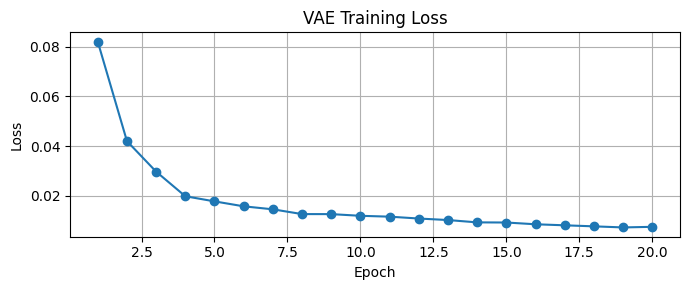

In [ ]:
vae_opt = optim.AdamW(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=LR, weight_decay=1e-4
)
KL_WEIGHT = 1e-4   # weight of KL term; increase gradually for sharper latents

vae_history = []

print("=" * 55)
print("  Training VAE")
print("=" * 55)

encoder.train(); decoder.train()

for epoch in range(VAE_EPOCHS):
    total_loss = recon_total = kl_total = 0.0
    vae_opt.zero_grad()

    for step, (imgs, _) in enumerate(dataloader):
        imgs = imgs.to(DEVICE)                                   # (B,3,H,W)
        B    = imgs.size(0)

        # Encoder
        enc_noise   = torch.randn(B, 4, LATENT_SIZE, LATENT_SIZE, device=DEVICE)
        z, mu, lv   = encoder(imgs, enc_noise)                   # z:(B,4,Lh,Lw)

        # Decoder
        recon        = decoder(z.clone())                        # (B,3,H,W)

        # Losses
        recon_loss   = F.mse_loss(recon, imgs)
        kl_loss      = vae_kl_loss(mu, lv)
        loss         = recon_loss + KL_WEIGHT * kl_loss

        # Grad accumulation
        (loss / GRAD_ACCUM).backward()
        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(dataloader):
            torch.nn.utils.clip_grad_norm_(
                list(encoder.parameters()) + list(decoder.parameters()), 1.0)
            vae_opt.step()
            vae_opt.zero_grad()

        total_loss   += loss.item()
        recon_total  += recon_loss.item()
        kl_total     += kl_loss.item()

    n     = len(dataloader)
    avg_l = total_loss / n
    vae_history.append(avg_l)
    print(f"  Epoch {epoch+1}/{VAE_EPOCHS} | "
          f"loss={avg_l:.4f}  recon={recon_total/n:.4f}  kl={kl_total/n:.4f}")

    free_mem()

print("\nVAE training done.")

# Loss plot
plt.figure(figsize=(7, 3))
plt.plot(range(1, len(vae_history)+1), vae_history, 'o-')
plt.title("VAE Training Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.grid(True); plt.tight_layout(); plt.show()


## 12. Train the Diffusion U-Net

> Standard DDPM objective: given a noisy latent `z_t`, predict the noise `ε`.
> The VAE encoder is **frozen** here — we only train the U-Net and CLIP text encoder.

  Training Diffusion U-Net
  Epoch 1/25 | loss=0.1356
  Epoch 2/25 | loss=0.0761
  Epoch 3/25 | loss=0.0699
  Epoch 4/25 | loss=0.0730
  Epoch 5/25 | loss=0.0690
  Epoch 6/25 | loss=0.0685
  Epoch 7/25 | loss=0.0661
  Epoch 8/25 | loss=0.0626
  Epoch 9/25 | loss=0.0613
  Epoch 10/25 | loss=0.0598
  Epoch 11/25 | loss=0.0589
  Epoch 12/25 | loss=0.0605
  Epoch 13/25 | loss=0.0611
  Epoch 14/25 | loss=0.0634
  Epoch 15/25 | loss=0.0590
  Epoch 16/25 | loss=0.0592
  Epoch 17/25 | loss=0.0635
  Epoch 18/25 | loss=0.0607
  Epoch 19/25 | loss=0.0562
  Epoch 20/25 | loss=0.0614
  Epoch 21/25 | loss=0.0607
  Epoch 22/25 | loss=0.0616
  Epoch 23/25 | loss=0.0579
  Epoch 24/25 | loss=0.0615
  Epoch 25/25 | loss=0.0580

Diffusion training done.


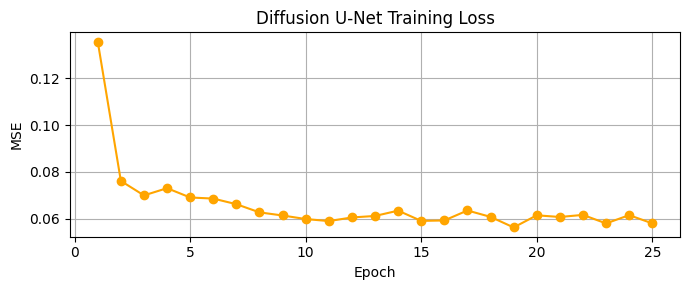

In [ ]:
diff_opt  = optim.AdamW(diffusion.parameters(), lr=LR, weight_decay=1e-4)
clip_opt  = optim.AdamW(clip_enc.parameters(),  lr=LR * 0.1, weight_decay=1e-4)

gen     = torch.Generator(device=DEVICE); gen.manual_seed(0)
sampler = DDPMSampler(gen)
sampler.set_inference_timesteps(INFER_STEPS)

diff_history = []

print("=" * 55)
print("  Training Diffusion U-Net")
print("=" * 55)

encoder.eval()   # keep VAE frozen
clip_enc.train(); diffusion.train()

for epoch in range(DIFFUSION_EPOCHS):
    epoch_loss = 0.0
    diff_opt.zero_grad(); clip_opt.zero_grad()

    for step, (imgs, tokens) in enumerate(dataloader):
        imgs   = imgs.to(DEVICE)      # (B,3,H,W)
        tokens = tokens.to(DEVICE)    # (B,T)
        B      = imgs.size(0)

        # 1. Encode images -> latents (no grad needed)
        with torch.no_grad():
            enc_noise = torch.randn(B, 4, LATENT_SIZE, LATENT_SIZE, device=DEVICE)
            z, _, _   = encoder(imgs, enc_noise)   # (B,4,Lh,Lw)

        # 2. Encode text -> context
        ctx = clip_enc(tokens)                      # (B, T, CLIP_DIM)

        # 3. Random timestep for each sample
        t_idx = torch.randint(0, sampler.num_train_steps, (B,), device=DEVICE)

        # 4. Add noise: q(z_t | z_0)
        z_t, noise = sampler.add_noise(z, t_idx)   # (B,4,Lh,Lw)

        # 5. Build time embeddings for the batch
        t_embs = torch.cat(
            [sinusoidal_time_embedding(ti.item()).to(DEVICE) for ti in t_idx], dim=0
        )   # (B, TIME_EMBD)

        # 6. Predict noise  ε̂ = U-Net(z_t, ctx, t)
        eps_pred = diffusion(z_t, ctx, t_embs)     # (B,4,Lh,Lw)

        # 7. MSE loss
        loss = F.mse_loss(eps_pred, noise)

        # 8. Backward + grad accumulation
        (loss / GRAD_ACCUM).backward()
        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(dataloader):
            torch.nn.utils.clip_grad_norm_(diffusion.parameters(), 1.0)
            diff_opt.step(); clip_opt.step()
            diff_opt.zero_grad(); clip_opt.zero_grad()

        epoch_loss += loss.item()

        # Free intermediate tensors aggressively
        del z_t, noise, eps_pred, ctx, z
        if step % 10 == 0:
            free_mem()

    avg = epoch_loss / len(dataloader)
    diff_history.append(avg)
    print(f"  Epoch {epoch+1}/{DIFFUSION_EPOCHS} | loss={avg:.4f}")
    free_mem()

print("\nDiffusion training done.")

plt.figure(figsize=(7, 3))
plt.plot(range(1, len(diff_history)+1), diff_history, 'o-', color='orange')
plt.title("Diffusion U-Net Training Loss"); plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.grid(True); plt.tight_layout(); plt.show()


## 13. Save / Load Checkpoints

In [ ]:
import pathlib

CKPT_DIR = pathlib.Path("checkpoints"); CKPT_DIR.mkdir(exist_ok=True)

def save_all(tag="latest"):
    torch.save(encoder.state_dict(),   CKPT_DIR / f"encoder_{tag}.pt")
    torch.save(decoder.state_dict(),   CKPT_DIR / f"decoder_{tag}.pt")
    torch.save(clip_enc.state_dict(),  CKPT_DIR / f"clip_{tag}.pt")
    torch.save(diffusion.state_dict(), CKPT_DIR / f"diffusion_{tag}.pt")
    print(f"Saved checkpoints with tag='{tag}' to {CKPT_DIR}/")

def load_all(tag="latest"):
    encoder.load_state_dict(torch.load(CKPT_DIR / f"encoder_{tag}.pt",
                                        map_location=DEVICE))
    decoder.load_state_dict(torch.load(CKPT_DIR / f"decoder_{tag}.pt",
                                        map_location=DEVICE))
    clip_enc.load_state_dict(torch.load(CKPT_DIR / f"clip_{tag}.pt",
                                         map_location=DEVICE))
    diffusion.load_state_dict(torch.load(CKPT_DIR / f"diffusion_{tag}.pt",
                                          map_location=DEVICE))
    print(f"Loaded checkpoints with tag='{tag}'")

save_all("final")


Saved checkpoints with tag='final' to checkpoints/


## 14. Inference — Generate Images

> **Text-to-image**: start from pure Gaussian noise, denoise guided by text.
> **Image-to-image**: start from a noisy version of an input, then denoise.

In [ ]:
@torch.no_grad()
def generate(
    prompt_tokens,
    uncond_tokens=None,
    input_image: torch.Tensor = None,
    strength: float = 0.8,
    do_cfg: bool = True,
    cfg_scale: float = 7.5,
    n_steps: int = INFER_STEPS,
    seed: int = 42,
) -> Image.Image:
    """
    Args
    ----
    prompt_tokens  : (1, SEQ_LEN) long tensor  — conditional tokens
    uncond_tokens  : (1, SEQ_LEN) long tensor  — unconditional tokens (for CFG)
                      If None, uses all-zero tokens.
    input_image    : (3, H, W)  float tensor in [-1,1]  — for img2img; None for t2i
    strength       : img2img noise strength (0=no change, 1=full noise)
    do_cfg         : whether to use classifier-free guidance
    cfg_scale      : guidance strength (typical 5–12)
    n_steps        : denoising steps
    seed           : RNG seed

    Returns
    -------
    PIL Image
    """
    encoder.eval(); decoder.eval(); clip_enc.eval(); diffusion.eval()

    g = torch.Generator(device=DEVICE); g.manual_seed(seed)
    inf_sampler = DDPMSampler(g); inf_sampler.set_inference_timesteps(n_steps)

    B = prompt_tokens.shape[0]

    # ── 1. Text context ──────────────────────────────────────────────────────
    prompt_tokens = prompt_tokens.to(DEVICE)
    cond_ctx   = clip_enc(prompt_tokens)                  # (1, T, D)

    if do_cfg:
        if uncond_tokens is None:
            uncond_tokens = torch.zeros_like(prompt_tokens)
        uncond_ctx = clip_enc(uncond_tokens.to(DEVICE))   # (1, T, D)
        context    = torch.cat([cond_ctx, uncond_ctx])    # (2, T, D)
    else:
        context    = cond_ctx                             # (1, T, D)

    # ── 2. Initial latent ────────────────────────────────────────────────────
    lat_shape = (1, 4, LATENT_SIZE, LATENT_SIZE)

    if input_image is not None:
        # img2img: encode then add noise
        img_t = input_image.unsqueeze(0).to(DEVICE)       # (1,3,H,W)
        enc_n = torch.randn(*lat_shape, generator=g, device=DEVICE)
        z0, _, _ = encoder(img_t, enc_n)
        inf_sampler.set_strength(strength)
        z, _ = inf_sampler.add_noise(z0, inf_sampler.timesteps[:1])
        print(f"  [img2img] latent shape : {tuple(z.shape)}")
    else:
        # t2i: pure noise
        z = torch.randn(*lat_shape, generator=g, device=DEVICE)
        print(f"  [t2i] latent shape : {tuple(z.shape)}")

    # ── 3. Denoising loop ────────────────────────────────────────────────────
    for i, t in enumerate(inf_sampler.timesteps):
        t_val = t.item()
        t_emb = sinusoidal_time_embedding(t_val).to(DEVICE)   # (1, TIME_EMBD)

        if do_cfg:
            z_in   = z.repeat(2, 1, 1, 1)                    # (2,4,Lh,Lw)
            t_in   = t_emb.repeat(2, 1)                       # (2, TIME_EMBD)
        else:
            z_in   = z; t_in = t_emb

        eps    = diffusion(z_in, context, t_in)               # (2or1,4,Lh,Lw)

        if do_cfg:
            eps_cond, eps_uncond = eps.chunk(2)
            eps = eps_uncond + cfg_scale * (eps_cond - eps_uncond)

        z = inf_sampler.step(t_val, z, eps)

    print(f"  decoded latent shape : {tuple(z.shape)}")

    # ── 4. Decode ────────────────────────────────────────────────────────────
    img_out = decoder(z)                                      # (1,3,H,W)
    print(f"  decoder output shape : {tuple(img_out.shape)}")
    return tensor_to_pil(img_out[0])


## 15. Text-to-Image Generation

> We pick a **real CIFAR-10 class** (e.g. "cat", "ship") and convert its label  
> to a token sequence.  The model generates an image from pure noise guided  
> by that class token sequence.


Generating class : 3 (cat)
Prompt tokens    : [39, 46, 53, 60, 67, 74, 81, 88, 95, 102, 109, 116, 123, 130, 137, 144]
Prompt shape     : (1, 16)
  [t2i] latent shape : (1, 4, 8, 8)
  decoded latent shape : (1, 4, 8, 8)
  decoder output shape : (1, 3, 64, 64)


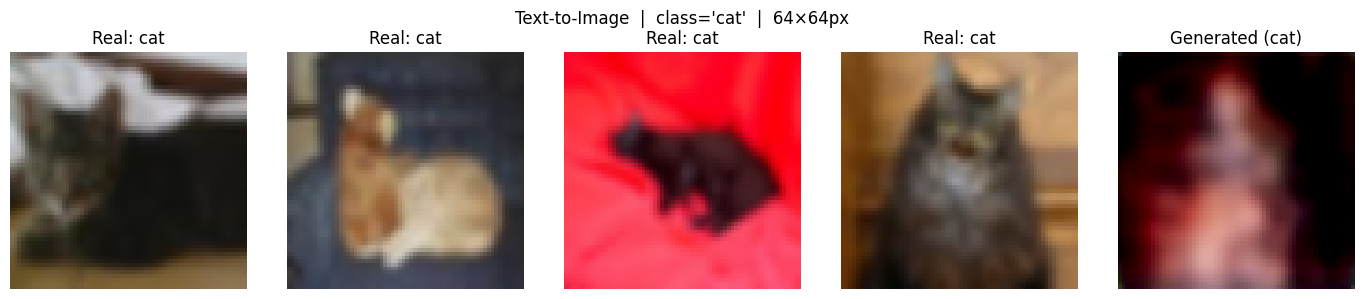

Generated image size : (64, 64)


In [ ]:
# ── Pick a class to generate ──────────────────────────────────────────────────
# Change TARGET_CLASS to any of:
# 0=airplane  1=automobile  2=bird  3=cat  4=deer
# 5=dog       6=frog        7=horse 8=ship 9=truck
TARGET_CLASS = 3   # "cat"

prompt_tokens = label_to_tokens(TARGET_CLASS).unsqueeze(0)  # (1, SEQ_LEN)
uncond_tokens = label_to_tokens(0).unsqueeze(0)             # use class-0 as negative

print(f"Generating class : {TARGET_CLASS} ({CIFAR_CLASSES[TARGET_CLASS]})")
print(f"Prompt tokens    : {prompt_tokens[0].tolist()}")
print(f"Prompt shape     : {tuple(prompt_tokens.shape)}")

out_t2i = generate(
    prompt_tokens  = prompt_tokens,
    uncond_tokens  = uncond_tokens,
    do_cfg         = True,
    cfg_scale      = 7.5,
    n_steps        = INFER_STEPS,
    seed           = 42,
)

# Also pull a real reference image for that class
ref_imgs = [dataset[i][0] for i in range(len(dataset))
            if dataset.cifar[dataset.indices[i]][1] == TARGET_CLASS][:4]

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for j, ri in enumerate(ref_imgs):
    axes[j].imshow(tensor_to_pil(ri))
    axes[j].set_title(f"Real: {CIFAR_CLASSES[TARGET_CLASS]}")
    axes[j].axis("off")
axes[4].imshow(out_t2i)
axes[4].set_title(f"Generated ({CIFAR_CLASSES[TARGET_CLASS]})")
axes[4].axis("off")
plt.suptitle(f"Text-to-Image  |  class='{CIFAR_CLASSES[TARGET_CLASS]}'  |  {IMAGE_SIZE}×{IMAGE_SIZE}px")
plt.tight_layout(); plt.show()
print(f"Generated image size : {out_t2i.size}")


## 16. Image-to-Image Generation

> We take a **real CIFAR-10 image**, add noise (controlled by `strength`),  
> then denoise it guided by a **different class label**.  
> Lower `strength` = stays closer to the source.  Higher = more hallucination.


Source class  : 8 (ship)
Target class  : 0 (airplane)
Source tensor : (3, 64, 64)  min=-0.91  max=0.96
  [img2img] latent shape : (1, 4, 8, 8)
  decoded latent shape : (1, 4, 8, 8)
  decoder output shape : (1, 3, 64, 64)


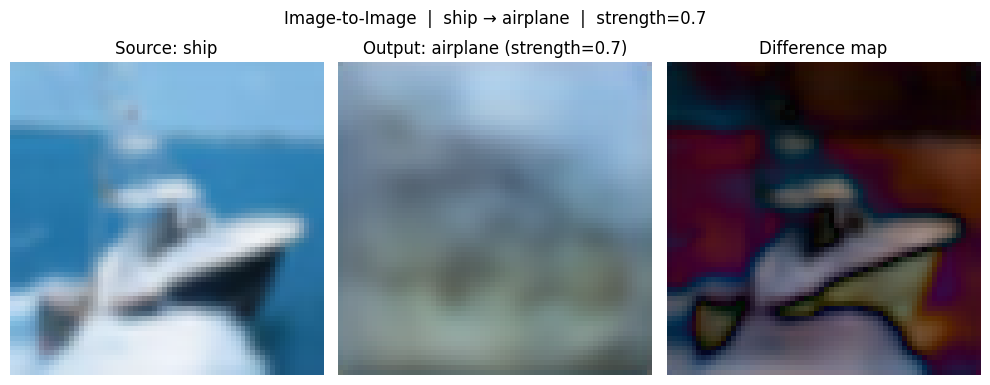

Output PIL size : (64, 64)


In [ ]:
# ── Pick a real source image ──────────────────────────────────────────────────
SRC_CLASS    = 8   # "ship"  — the source image class
TGT_CLASS    = 0   # "airplane" — the target style/class

# Find first sample of SRC_CLASS
src_idx = next(i for i in range(len(dataset))
               if dataset.cifar[dataset.indices[i]][1] == SRC_CLASS)
src_tensor, _ = dataset[src_idx]    # (3, IMAGE_SIZE, IMAGE_SIZE)

prompt_tokens_i2i = label_to_tokens(TGT_CLASS).unsqueeze(0)   # (1, SEQ_LEN)
uncond_tokens_i2i = label_to_tokens(0).unsqueeze(0)

print(f"Source class  : {SRC_CLASS} ({CIFAR_CLASSES[SRC_CLASS]})")
print(f"Target class  : {TGT_CLASS} ({CIFAR_CLASSES[TGT_CLASS]})")
print(f"Source tensor : {tuple(src_tensor.shape)}  "
      f"min={src_tensor.min():.2f}  max={src_tensor.max():.2f}")

STRENGTH = 0.7   # 0=no change  1=completely new image

out_i2i = generate(
    prompt_tokens  = prompt_tokens_i2i,
    uncond_tokens  = uncond_tokens_i2i,
    input_image    = src_tensor,
    strength       = STRENGTH,
    do_cfg         = True,
    cfg_scale      = 7.5,
    n_steps        = INFER_STEPS,
    seed           = 42,
)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(tensor_to_pil(src_tensor))
axes[0].set_title(f"Source: {CIFAR_CLASSES[SRC_CLASS]}")
axes[0].axis("off")
axes[1].imshow(out_i2i)
axes[1].set_title(f"Output: {CIFAR_CLASSES[TGT_CLASS]} (strength={STRENGTH})")
axes[1].axis("off")
# Difference map
src_arr = np.array(tensor_to_pil(src_tensor)).astype(float)
out_arr = np.array(out_i2i).astype(float)
diff    = np.abs(src_arr - out_arr).astype(np.uint8)
axes[2].imshow(diff)
axes[2].set_title("Difference map")
axes[2].axis("off")
plt.suptitle(f"Image-to-Image  |  {CIFAR_CLASSES[SRC_CLASS]} → {CIFAR_CLASSES[TGT_CLASS]}  |  strength={STRENGTH}")
plt.tight_layout(); plt.show()
print(f"Output PIL size : {out_i2i.size}")


## 17. VAE Reconstruction Test

> Encode real CIFAR-10 images into latents, then decode back.  
> This shows how well the VAE has learned to compress and reconstruct real images.


Input  shape : (5, 3, 64, 64)
Latent shape : (5, 4, 8, 8)
Recon  shape : (5, 3, 64, 64)
Classes shown: ['frog', 'truck', 'deer', 'automobile', 'bird']


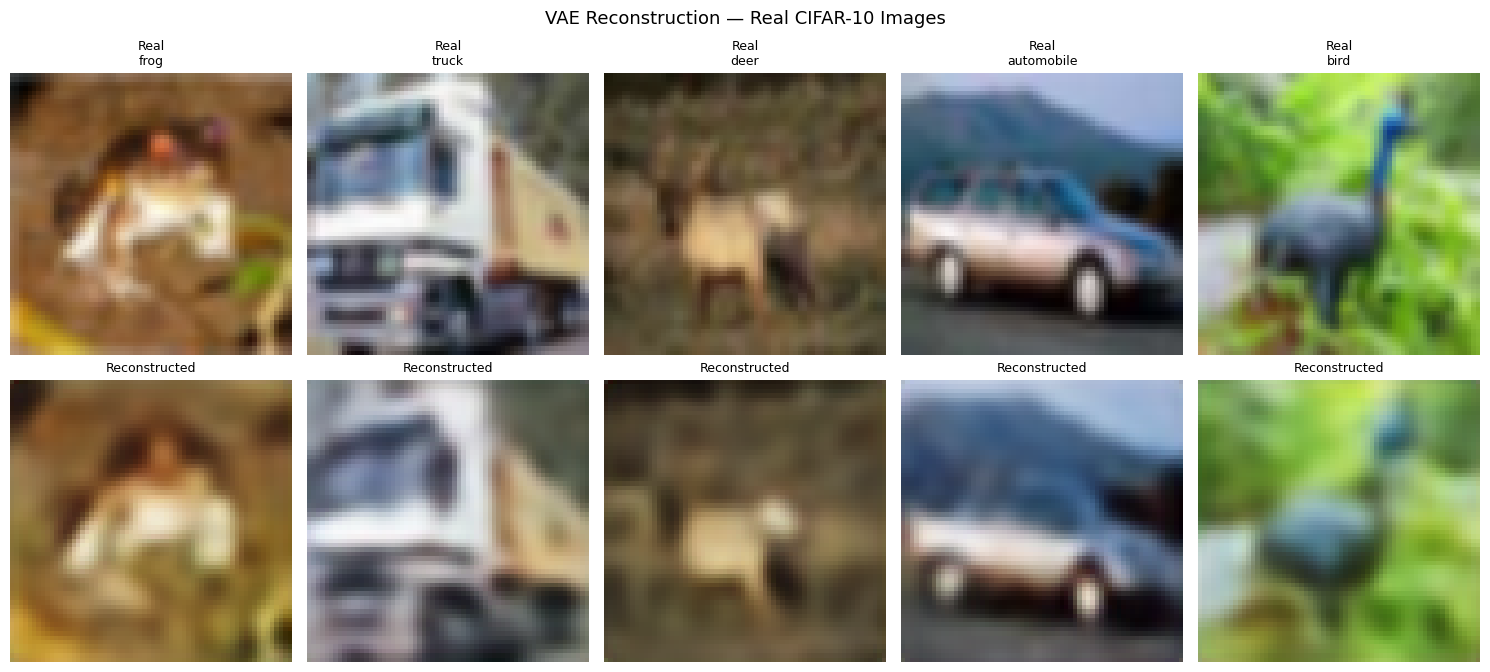

In [ ]:
encoder.eval(); decoder.eval()

# Use one image per class for variety
class_indices = {}
for i in range(len(dataset)):
    lbl = dataset.cifar[dataset.indices[i]][1]
    if lbl not in class_indices:
        class_indices[lbl] = i
    if len(class_indices) == 10:
        break

n_show   = min(5, len(class_indices))
show_idx = list(class_indices.values())[:n_show]
imgs     = torch.stack([dataset[i][0] for i in show_idx]).to(DEVICE)
labels   = [dataset.cifar[dataset.indices[i]][1] for i in show_idx]

with torch.no_grad():
    enc_n      = torch.zeros(n_show, 4, LATENT_SIZE, LATENT_SIZE, device=DEVICE)
    z, mu, lv  = encoder(imgs, enc_n)
    z_det      = mu * 0.18215           # deterministic: use mean, no noise
    recon      = decoder(z_det)

print(f"Input  shape : {tuple(imgs.shape)}")
print(f"Latent shape : {tuple(z_det.shape)}")
print(f"Recon  shape : {tuple(recon.shape)}")
print(f"Classes shown: {[CIFAR_CLASSES[l] for l in labels]}")

fig, axes = plt.subplots(2, n_show, figsize=(3*n_show, 7))
for i in range(n_show):
    axes[0, i].imshow(tensor_to_pil(imgs[i].cpu()))
    axes[0, i].set_title(f"Real\n{CIFAR_CLASSES[labels[i]]}", fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].imshow(tensor_to_pil(recon[i].cpu()))
    axes[1, i].set_title("Reconstructed", fontsize=9)
    axes[1, i].axis("off")
plt.suptitle("VAE Reconstruction — Real CIFAR-10 Images", fontsize=13)
plt.tight_layout(); plt.show()


## 18. Complete Shape Summary

All key tensor shapes at a glance:

In [ ]:
print("=" * 65)
print(f"  {'MODULE':<25} {'INPUT':<22} {'OUTPUT'}")
print("=" * 65)
rows = [
  ("VAE Encoder",     f"(B,3,{IMAGE_SIZE},{IMAGE_SIZE})",     f"(B,4,{LATENT_SIZE},{LATENT_SIZE}) + mean + logvar"),
  ("VAE Decoder",     f"(B,4,{LATENT_SIZE},{LATENT_SIZE})",   f"(B,3,{IMAGE_SIZE},{IMAGE_SIZE})"),
  ("CLIP",            f"(B,{SEQ_LEN})",                        f"(B,{SEQ_LEN},{CLIP_DIM})"),
  ("TimeEmbedding",   "scalar t",                              f"(1,{TIME_EMBD})  ->  (B,4*{TIME_EMBD})"),
  ("Diffusion U-Net", f"(B,4,{LATENT_SIZE},{LATENT_SIZE})",   f"(B,4,{LATENT_SIZE},{LATENT_SIZE})  noise pred"),
  ("DDPM add_noise",  f"(B,4,{LATENT_SIZE},{LATENT_SIZE})",   f"same  noisy_z + noise"),
  ("DDPM step",       f"(B,4,{LATENT_SIZE},{LATENT_SIZE})",   f"same  x_{{t-1}}"),
]
for name, inp, out in rows:
    print(f"  {name:<25} {inp:<22} {out}")
print("=" * 65)


  MODULE                    INPUT                  OUTPUT
  VAE Encoder               (B,3,64,64)            (B,4,8,8) + mean + logvar
  VAE Decoder               (B,4,8,8)              (B,3,64,64)
  CLIP                      (B,16)                 (B,16,128)
  TimeEmbedding             scalar t               (1,128)  ->  (B,4*128)
  Diffusion U-Net           (B,4,8,8)              (B,4,8,8)  noise pred
  DDPM add_noise            (B,4,8,8)              same  noisy_z + noise
  DDPM step                 (B,4,8,8)              same  x_{t-1}
